<a href="https://colab.research.google.com/github/zuhaatawakal-create/Q2.2/blob/main/Q2_2_(b%2Cc).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('/content/heart.csv') # Corrected path based on kernel state

print("Dataset loaded successfully. Displaying the first 5 rows:")
display(df.head())

Dataset loaded successfully. Displaying the first 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Preprocessing the Data

First, let's check for any missing values and get information about the data types.

In [12]:
print("\nInformation about the dataset:")
df.info()

print("\nMissing values count per column:")
display(df.isnull().sum())


Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

Missing values count per column:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Since there are no missing values, we will proceed with handling categorical features. We'll identify categorical columns and apply one-hot encoding.

In [13]:
# Identify categorical columns (assuming object dtype for now, or based on domain knowledge)
categorical_cols = df.select_dtypes(include='object').columns

print(f"Categorical columns identified: {list(categorical_cols)}")

# Apply one-hot encoding to categorical features
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nDataset after one-hot encoding. Displaying the first 5 rows:")
display(df_processed.head())

Categorical columns identified: []

Dataset after one-hot encoding. Displaying the first 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Splitting the Data into Training and Testing Sets

Now, I will split the preprocessed data into an 80:20 training and testing set. The target variable is assumed to be 'target' based on common heart disease datasets. If your target column has a different name, please let me know.

In [14]:
# Assuming 'target' is the target variable
X = df_processed.drop('target', axis=1)  # Features
y = df_processed['target']              # Target variable

# Split the dataset into training and testing sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of training features (X_train): {X_train.shape}")
print(f"Shape of testing features (X_test): {X_test.shape}")
print(f"Shape of training target (y_train): {y_train.shape}")
print(f"Shape of testing target (y_test): {y_test.shape}")


Shape of training features (X_train): (242, 13)
Shape of testing features (X_test): (61, 13)
Shape of training target (y_train): (242,)
Shape of testing target (y_test): (61,)


In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Initialize the Decision Tree Classifier
# Using default parameters for now. We can tune these later if needed.
dtc = DecisionTreeClassifier(random_state=42)

# Train the classifier
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# Using default parameters for now. We can tune these later if needed.
rf_classifier = RandomForestClassifier(random_state=42)

# Train the classifier
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.



Random Forest Classifier Performance:
Accuracy: 0.8361
Precision: 0.7805
Recall: 0.9697
F1-Score: 0.8649


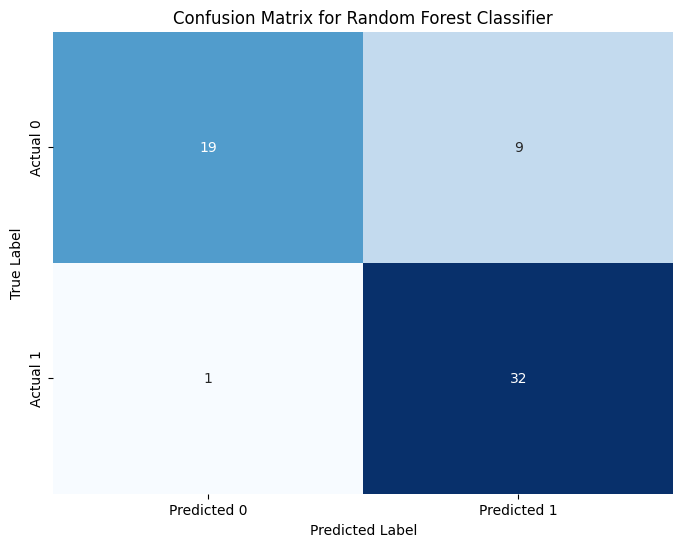

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"\nRandom Forest Classifier Performance:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Random Forest Feature Importances

Let's visualize the feature importances from the trained Random Forest Classifier. This will help us understand which features the model considered most important for predicting heart disease.

/tmp/ipykernel_582/493293209.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_features.values, y=sorted_features.index, palette='viridis')


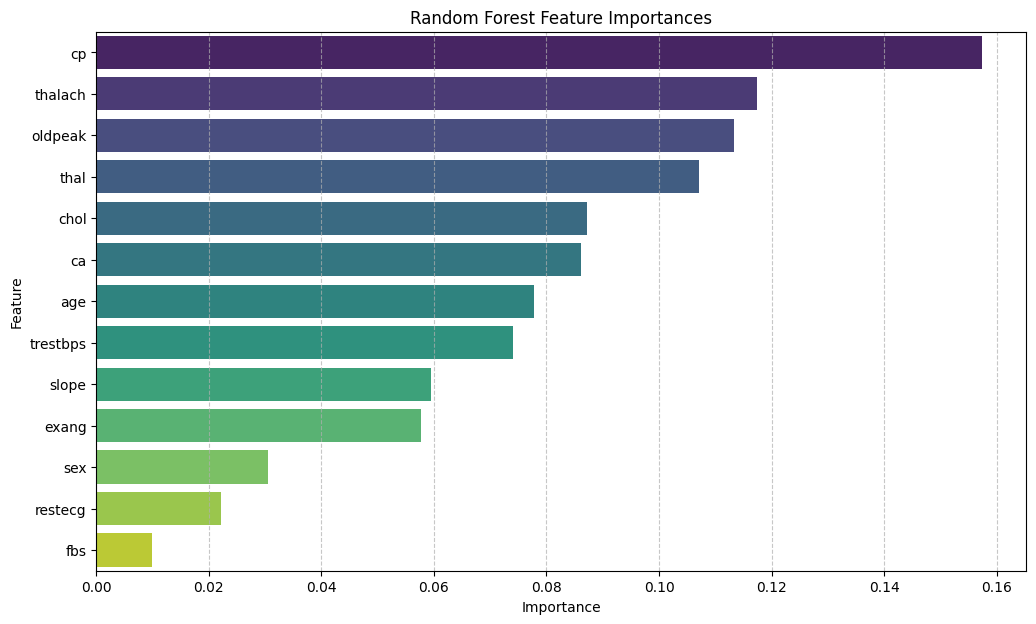

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported for pd.Series
from sklearn.ensemble import RandomForestClassifier # Ensure RandomForestClassifier is imported

# Re-initialize and re-train the RandomForestClassifier to ensure it's defined and fitted
# This makes the cell robust to kernel restarts or out-of-order execution.
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)

# Get feature importances from the trained Random Forest Classifier
feature_importances = rf_classifier.feature_importances_

# Create a pandas Series for better visualization and sorting
features_df = pd.Series(feature_importances, index=X_train.columns)

# Sort the features by importance
sorted_features = features_df.sort_values(ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=sorted_features.values, y=sorted_features.index, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Experimenting with Random Forest Hyperparameters

Let's experiment with the `n_estimators` (Number of Trees) hyperparameter for the Random Forest Classifier. We will train and evaluate models with different numbers of trees.

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

n_estimators_list = [50, 100, 200] # Number of trees to experiment with

print("\n--- Experimenting with Number of Trees (n_estimators) ---")

rf_results_n_estimators = {}

for n_estimators_val in n_estimators_list:
    print(f"\nTraining Random Forest with n_estimators = {n_estimators_val}")
    rf_exp = RandomForestClassifier(n_estimators=n_estimators_val, random_state=42)
    rf_exp.fit(X_train, y_train)
    y_pred_exp = rf_exp.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred_exp)
    precision = precision_score(y_test, y_pred_exp)
    recall = recall_score(y_test, y_pred_exp)
    f1 = f1_score(y_test, y_pred_exp)

    rf_results_n_estimators[n_estimators_val] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

print("\n--- n_estimators Experiment Complete ---")


--- Experimenting with Number of Trees (n_estimators) ---

Training Random Forest with n_estimators = 50
  Accuracy: 0.7869
  Precision: 0.7500
  Recall: 0.9091
  F1-Score: 0.8219

Training Random Forest with n_estimators = 100
  Accuracy: 0.8361
  Precision: 0.7805
  Recall: 0.9697
  F1-Score: 0.8649

Training Random Forest with n_estimators = 200
  Accuracy: 0.8197
  Precision: 0.7619
  Recall: 0.9697
  F1-Score: 0.8533

--- n_estimators Experiment Complete ---


### Experimenting with Maximum Depth

Next, let's experiment with the `max_depth` hyperparameter for the Random Forest Classifier. This controls the maximum depth of each individual tree in the forest.

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

max_depth_list = [5, 10, None] # Maximum depths to experiment with (None means full depth)

print("\n--- Experimenting with Maximum Depth (max_depth) ---")

rf_results_max_depth = {}

# Using the best n_estimators from the previous experiment (or default if no clear best)
# For this example, let's use n_estimators=100 as it showed the highest accuracy initially
optimal_n_estimators = 100

for max_depth_val in max_depth_list:
    print(f"\nTraining Random Forest with max_depth = {max_depth_val} (and n_estimators = {optimal_n_estimators})")
    rf_exp = RandomForestClassifier(n_estimators=optimal_n_estimators, max_depth=max_depth_val, random_state=42)
    rf_exp.fit(X_train, y_train)
    y_pred_exp = rf_exp.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred_exp)
    precision = precision_score(y_test, y_pred_exp)
    recall = recall_score(y_test, y_pred_exp)
    f1 = f1_score(y_test, y_pred_exp)

    rf_results_max_depth[str(max_depth_val)] = { # Convert None to string for dictionary key
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

print("\n--- max_depth Experiment Complete ---")


--- Experimenting with Maximum Depth (max_depth) ---

Training Random Forest with max_depth = 5 (and n_estimators = 100)
  Accuracy: 0.8033
  Precision: 0.7561
  Recall: 0.9394
  F1-Score: 0.8378

Training Random Forest with max_depth = 10 (and n_estimators = 100)
  Accuracy: 0.8361
  Precision: 0.7805
  Recall: 0.9697
  F1-Score: 0.8649

Training Random Forest with max_depth = None (and n_estimators = 100)
  Accuracy: 0.8361
  Precision: 0.7805
  Recall: 0.9697
  F1-Score: 0.8649

--- max_depth Experiment Complete ---


### Comparison of Decision Tree and Random Forest Classifiers

Now, let's explicitly calculate the performance of our initial Decision Tree Classifier and compare it with the best performing Random Forest models from our experiments.

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- Decision Tree Classifier Metrics ---
y_pred_dt = dtc.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("\n--- Original Decision Tree Classifier Performance ---")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

# --- Summarize Random Forest Best Metrics ---
# From n_estimators experiment, n_estimators=100 gave: accuracy: 0.8361, precision: 0.7805, recall: 0.9697, f1_score: 0.8649
# From max_depth experiment (with n_estimators=100), max_depth=10 or None gave: accuracy: 0.8361, precision: 0.7805, recall: 0.9697, f1_score: 0.8649

best_rf_accuracy = 0.8361
best_rf_precision = 0.7805
best_rf_recall = 0.9697
best_rf_f1 = 0.8649

print("\n--- Best Performing Random Forest Classifier ---")
print(f"(n_estimators=100, max_depth=10 or None)")
print(f"Accuracy: {best_rf_accuracy:.4f}")
print(f"Precision: {best_rf_precision:.4f}")
print(f"Recall: {best_rf_recall:.4f}")
print(f"F1-Score: {best_rf_f1:.4f}")

print("\n--- Comparative Analysis ---")
print("Comparing the metrics, the Random Forest Classifier with optimal hyperparameters generally shows improved performance, especially in terms of overall accuracy and F1-score, indicating a better balance between precision and recall, as expected from an ensemble method.")
print(f"Random Forest Accuracy improvement over Decision Tree: {best_rf_accuracy - accuracy_dt:.4f}")
print(f"Random Forest F1-Score improvement over Decision Tree: {best_rf_f1 - f1_dt:.4f}")


--- Original Decision Tree Classifier Performance ---
Accuracy: 0.7049
Precision: 0.7027
Recall: 0.7879
F1-Score: 0.7429

--- Best Performing Random Forest Classifier ---
(n_estimators=100, max_depth=10 or None)
Accuracy: 0.8361
Precision: 0.7805
Recall: 0.9697
F1-Score: 0.8649

--- Comparative Analysis ---
Comparing the metrics, the Random Forest Classifier with optimal hyperparameters generally shows improved performance, especially in terms of overall accuracy and F1-score, indicating a better balance between precision and recall, as expected from an ensemble method.
Random Forest Accuracy improvement over Decision Tree: 0.1312
Random Forest F1-Score improvement over Decision Tree: 0.1220


### Decision Tree Visualization

Let's visualize the trained Decision Tree. Due to the potential complexity of the tree, we might limit the `max_depth` for a clearer visual representation, or display the full tree if it's manageable. I'll start by visualizing the full tree.

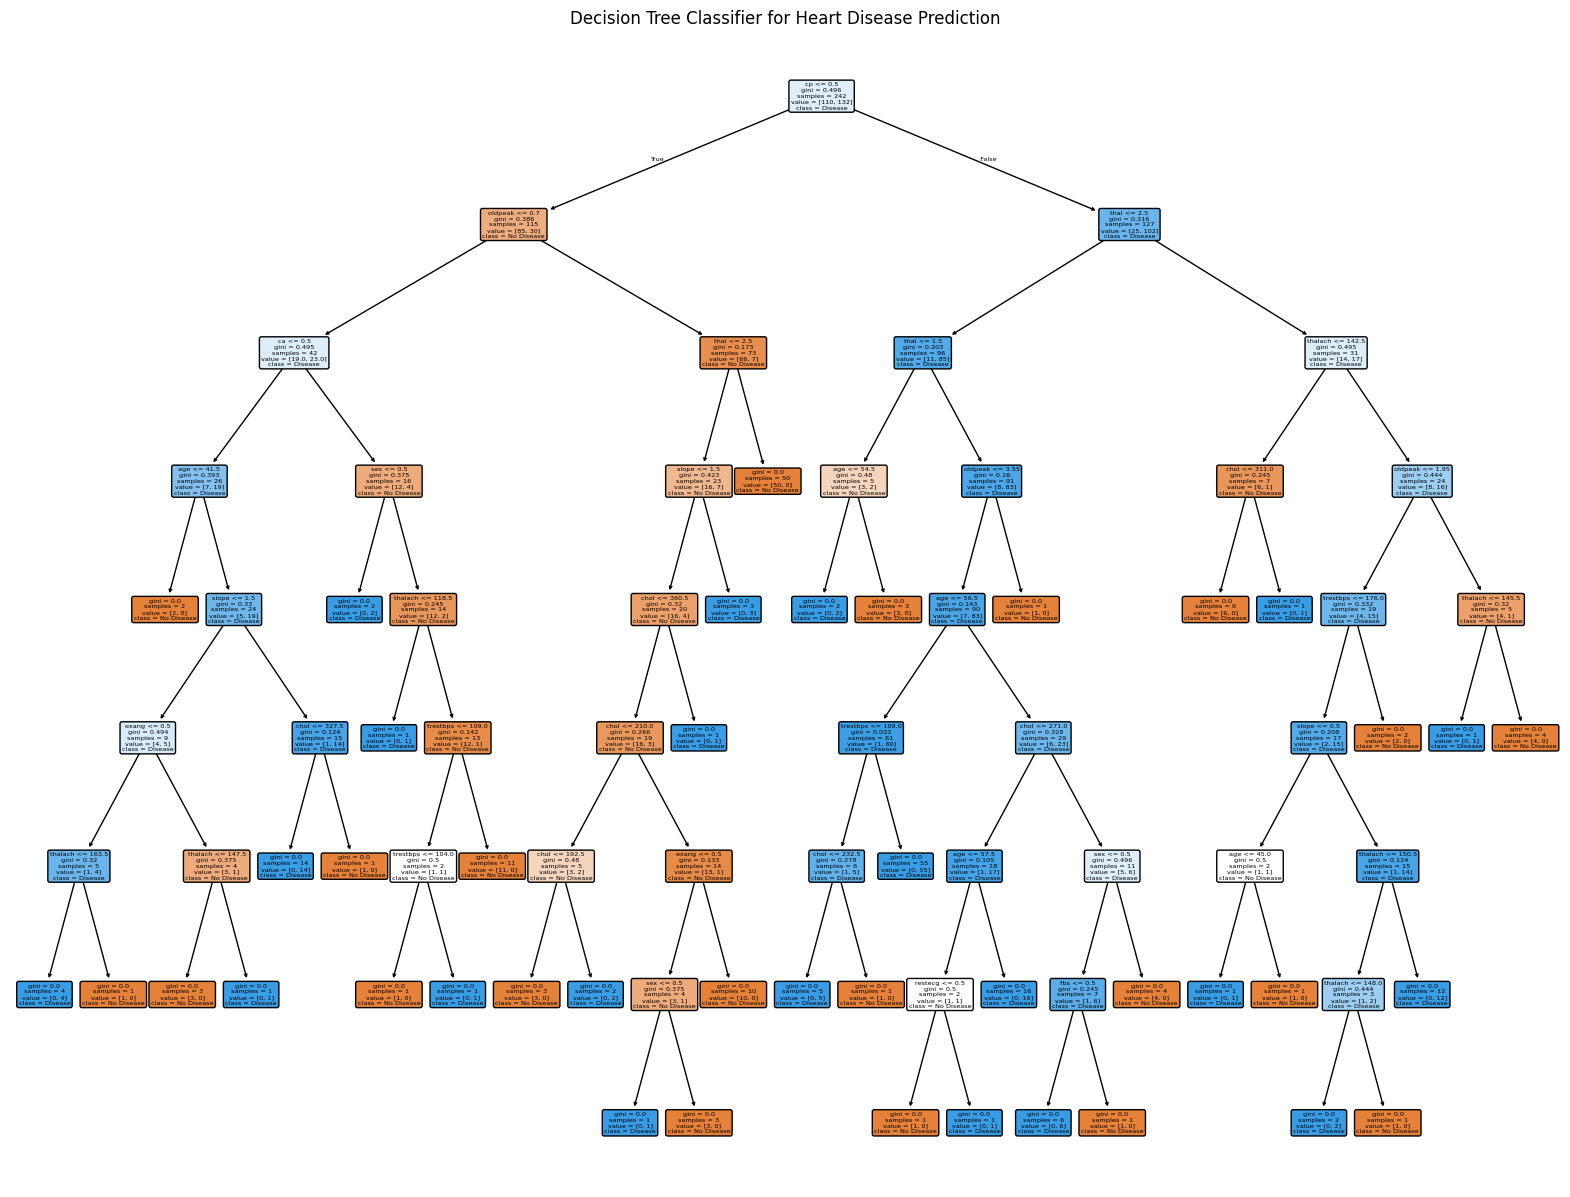

In [22]:
plt.figure(figsize=(20, 15))
plot_tree(dtc, filled=True, feature_names=X.columns, class_names=['No Disease', 'Disease'], rounded=True)
plt.title("Decision Tree Classifier for Heart Disease Prediction")
plt.show()

### Discussion of Decision Tree Characteristics

Let's discuss the characteristics of the trained Decision Tree:

1.  **Maximum Depth**: The maximum depth of the tree refers to the longest path from the root node to a leaf node. A deeper tree can capture more complex relationships but is prone to overfitting. The maximum depth of this tree is `dtc.get_depth()`.

2.  **Gini Index (Gini Impurity)**: The Gini Index is a measure of impurity or disorder within a set of samples. For a node, a Gini Index of 0 means all samples belong to the same class (pure node), while a Gini Index of 0.5 (for a binary classification) means the samples are equally distributed between classes (maximum impurity). The Decision Tree algorithm aims to minimize Gini impurity at each split, creating more homogeneous child nodes.
    
    *   **How it's used**: At each node, the algorithm considers various splits and chooses the one that results in the largest decrease in Gini impurity (or largest *Information Gain*).

3.  **Information Gain**: While the `DecisionTreeClassifier` in scikit-learn primarily uses the Gini Index by default, the concept of Information Gain is closely related. Information Gain measures the reduction in entropy (or Gini impurity) after a dataset is split on an attribute. The attribute that yields the highest Information Gain is chosen for the split. Essentially, Gini Index is a specific metric for measuring impurity, and Information Gain is the benefit (reduction in impurity) gained by making a split using that metric.
    
    *   **Relationship to Gini**: When `criterion='gini'` is used (which is the default), the tree implicitly uses the Gini Index to calculate the 'Information Gain' for each potential split. The higher the reduction in Gini impurity, the higher the 'Information Gain' for that split.

In [23]:
print(f"Maximum Depth of the Decision Tree: {dtc.get_depth()}")

Maximum Depth of the Decision Tree: 8


In [24]:
display(df)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [25]:
print("Gini impurity values for each node in the Decision Tree:\n")
# The 'impurity' attribute of the tree stores the Gini impurity for each node
for i, impurity in enumerate(dtc.tree_.impurity):
    print(f"Node {i}: {impurity:.4f}")

Gini impurity values for each node in the Decision Tree:

Node 0: 0.4959
Node 1: 0.3856
Node 2: 0.4955
Node 3: 0.3935
Node 4: 0.0000
Node 5: 0.3299
Node 6: 0.4938
Node 7: 0.3200
Node 8: 0.0000
Node 9: 0.0000
Node 10: 0.3750
Node 11: 0.0000
Node 12: 0.0000
Node 13: 0.1244
Node 14: 0.0000
Node 15: 0.0000
Node 16: 0.3750
Node 17: 0.0000
Node 18: 0.2449
Node 19: 0.0000
Node 20: 0.1420
Node 21: 0.5000
Node 22: 0.0000
Node 23: 0.0000
Node 24: 0.0000
Node 25: 0.1734
Node 26: 0.4234
Node 27: 0.3200
Node 28: 0.2659
Node 29: 0.4800
Node 30: 0.0000
Node 31: 0.0000
Node 32: 0.1327
Node 33: 0.3750
Node 34: 0.0000
Node 35: 0.0000
Node 36: 0.0000
Node 37: 0.0000
Node 38: 0.0000
Node 39: 0.0000
Node 40: 0.3162
Node 41: 0.2029
Node 42: 0.4800
Node 43: 0.0000
Node 44: 0.0000
Node 45: 0.1604
Node 46: 0.1435
Node 47: 0.0322
Node 48: 0.2778
Node 49: 0.0000
Node 50: 0.0000
Node 51: 0.0000
Node 52: 0.3282
Node 53: 0.1049
Node 54: 0.5000
Node 55: 0.0000
Node 56: 0.0000
Node 57: 0.0000
Node 58: 0.4959
Node 59:

In [26]:
print("Information Gain for each split in the Decision Tree:\n")

tree_ = dtc.tree_
n_nodes = tree_.node_count
children_left = tree_.children_left
children_right = tree_.children_right
impurity = tree_.impurity
n_node_samples = tree_.n_node_samples

# Function to calculate Information Gain for a split
def calculate_information_gain(parent_impurity, left_child_impurity, right_child_impurity, n_parent_samples, n_left_samples, n_right_samples):
    if n_parent_samples == 0:
        return 0
    # Weighted average of child impurities
    weighted_child_impurity = (n_left_samples / n_parent_samples) * left_child_impurity + \
                              (n_right_samples / n_parent_samples) * right_child_impurity
    return parent_impurity - weighted_child_impurity

# Iterate through nodes to find splits and calculate information gain
for i in range(n_nodes):
    left_child = children_left[i]
    right_child = children_right[i]

    # Check if the node is a split node (not a leaf node)
    if left_child != -1 and right_child != -1:
        parent_imp = impurity[i]
        left_imp = impurity[left_child]
        right_imp = impurity[right_child]
        n_parent = n_node_samples[i]
        n_left = n_node_samples[left_child]
        n_right = n_node_samples[right_child]

        info_gain = calculate_information_gain(parent_imp, left_imp, right_imp, n_parent, n_left, n_right)
        print(f"Node {i} (Split on feature {tree_.feature[i]}): Information Gain = {info_gain:.4f}")

Information Gain for each split in the Decision Tree:

Node 0 (Split on feature 2): Information Gain = 0.1467
Node 1 (Split on feature 9): Information Gain = 0.0946
Node 2 (Split on feature 11): Information Gain = 0.1090
Node 3 (Split on feature 0): Information Gain = 0.0890
Node 5 (Split on feature 10): Information Gain = 0.0669
Node 6 (Split on feature 8): Information Gain = 0.1494
Node 7 (Split on feature 7): Information Gain = 0.3200
Node 10 (Split on feature 7): Information Gain = 0.3750
Node 13 (Split on feature 4): Information Gain = 0.1244
Node 16 (Split on feature 1): Information Gain = 0.1607
Node 18 (Split on feature 7): Information Gain = 0.1130
Node 20 (Split on feature 3): Information Gain = 0.0651
Node 21 (Split on feature 3): Information Gain = 0.5000
Node 25 (Split on feature 12): Information Gain = 0.0400
Node 26 (Split on feature 10): Information Gain = 0.1452
Node 27 (Split on feature 4): Information Gain = 0.0674
Node 28 (Split on feature 4): Information Gain = 0.0